<span style="color: purple; font-family: 'Georgia', serif; font-size: 28px; font-weight: bold;">
SALES PREDICTION
</span>


IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

IMPORT DATASET

In [3]:
df=pd.read_csv("practiceDataset.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


CHECKING THE DATATYPES

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

CHECKING FOR NULL VALUES

In [112]:
df.isnull().sum().sum()

np.int64(0)

STATISTICAL SUMMARY OF THE DATASET

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


CHECKING THE COLUMNS

In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

CHECKING THE UNIQUE VALUES

In [8]:
df['SalePrice'].nunique()

663

CHECKING FOR VALUE COUNTS

In [9]:
df["SalePrice"].value_counts()

SalePrice
140000    20
135000    17
145000    14
155000    14
190000    13
          ..
410000     1
156932     1
144152     1
216000     1
274300     1
Name: count, Length: 663, dtype: int64

CHECKING FOR COLUMNS WHICH HAS NULL VALUES

In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

FILLING THE NULL VALUES

In [11]:
from sklearn.impute import SimpleImputer
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
num_imputer = SimpleImputer(strategy='mean')            
cat_imputer = SimpleImputer(strategy='most_frequent')  
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

EXPLORATORY DATA ANALYSIS

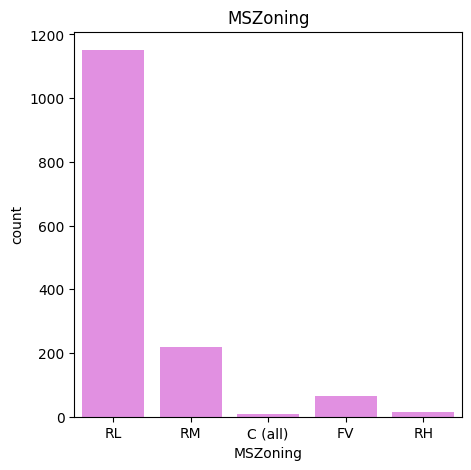

In [12]:
plt.figure(figsize=(5,5))
sns.countplot(x="MSZoning",data=df,color="violet")
plt.title("MSZoning")                                     #COUNTPLOT
plt.show()

<span style="color: NAVYBLUE;">
Here the RL has more count
</span>


BAR PLOT

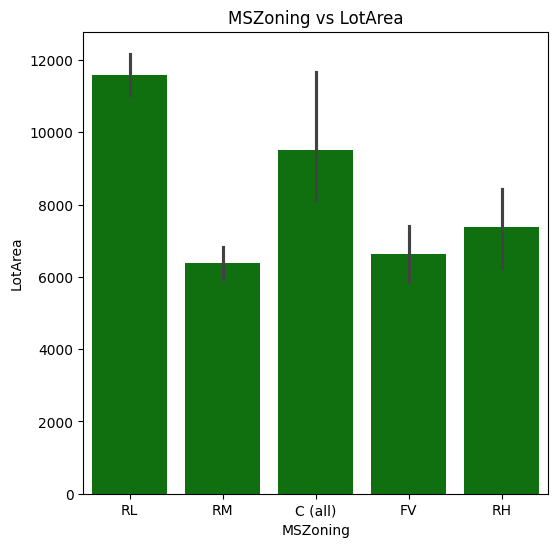

In [13]:
plt.figure(figsize=(6,6))
sns.barplot(x="MSZoning",y="LotArea",data=df,color="green")
plt.title("MSZoning vs LotArea")
plt.show()

<span style="color: violet;">
Here the RL and C(all) has more count
</span>


HISTOGRAM

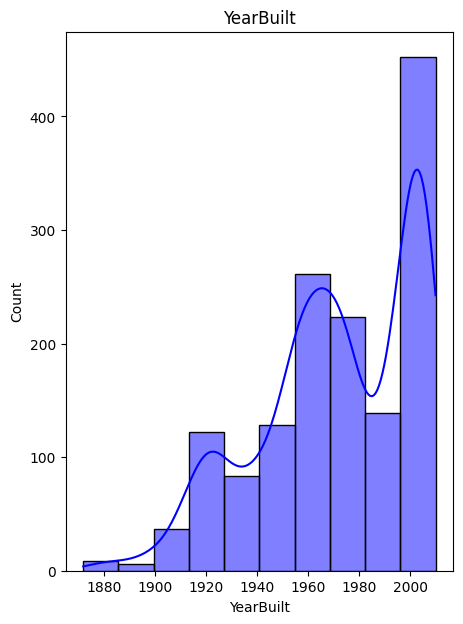

In [14]:
plt.figure(figsize=(5,7))
sns.histplot(x="YearBuilt",bins=10,kde="True",data=df,color="blue")
plt.title("YearBuilt")
plt.show()

<span style="color: green;">
This plot shows that most houses were built after 1950, with a sharp increase in construction after 2000.
</span>


PIECHART

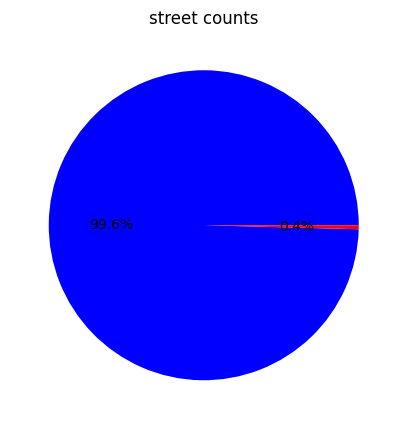

In [15]:
plt.figure(figsize=(5,6))
street_counts=df["Street"].value_counts()
plt.pie(street_counts,colors=["blue","red"],autopct="%1.1f%%")
plt.title("street counts")
plt.show()

<span style="color: yellow;">
Pave is more in count when compared with Gvrl.
</span>


In [16]:
df["Street"].value_counts()

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

BOX PLOT

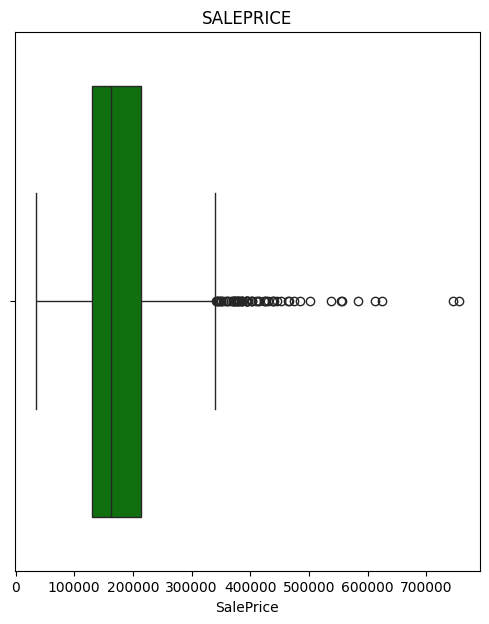

In [17]:
plt.figure(figsize=(6,7))
sns.boxplot(x="SalePrice",color="green",data=df)
plt.title("SALEPRICE")
plt.show()

<span style="color: blue;">
The boxplot shows that SalePrice has many high-value outliers, indicating a heavily right-skewed distribution.
</span>


SCATTER PLOT

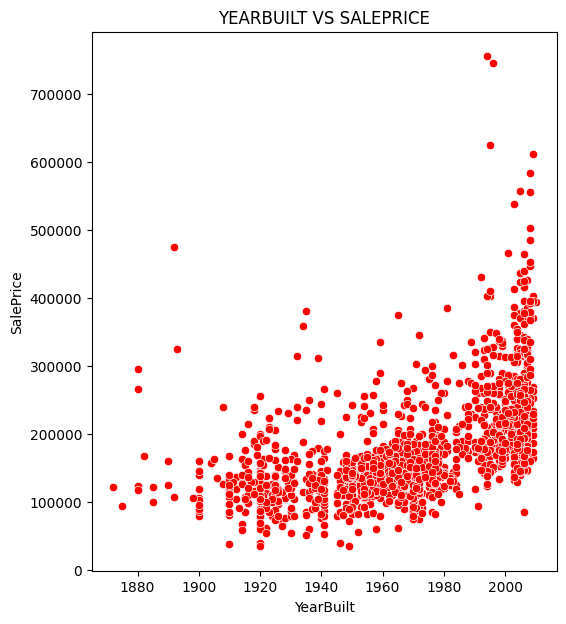

In [18]:
plt.figure(figsize=(6,7))
sns.scatterplot(x="YearBuilt",y="SalePrice",data=df,color="red")
plt.title("YEARBUILT VS SALEPRICE")
plt.show()

<span style="color: orange;">
The scatter plot shows that SalePrice increases as the feature value rises, indicating a strong positive relationship with some high-value outliers.
</span>


DROPPING THE UNNECESSARY COLUMNS

In [19]:
df.drop(columns=["Id"],inplace=True)

In [20]:
df.drop(columns=["Alley"],inplace=True)

In [21]:
df.drop(columns=["PoolQC"],inplace=True)

In [22]:
df.drop(columns=["Fence"],inplace=True)

In [23]:
df.drop(columns=["MiscFeature"],inplace=True)

In [24]:
df.drop(columns=["MiscVal"],inplace=True)

In [25]:
df.drop(columns=["Street"],inplace=True)

In [26]:
df.drop(columns=["Utilities"],inplace=True)

In [27]:
df.drop(columns=["Condition2"],inplace=True)

In [28]:
df.drop(columns=["RoofMatl"],inplace=True)

In [29]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60.0,RL,65.0,8450.0,Reg,Lvl,Inside,Gtl,CollgCr,Norm,...,61.0,0.0,0.0,0.0,0.0,2.0,2008.0,WD,Normal,208500.0
1,20.0,RL,80.0,9600.0,Reg,Lvl,FR2,Gtl,Veenker,Feedr,...,0.0,0.0,0.0,0.0,0.0,5.0,2007.0,WD,Normal,181500.0
2,60.0,RL,68.0,11250.0,IR1,Lvl,Inside,Gtl,CollgCr,Norm,...,42.0,0.0,0.0,0.0,0.0,9.0,2008.0,WD,Normal,223500.0
3,70.0,RL,60.0,9550.0,IR1,Lvl,Corner,Gtl,Crawfor,Norm,...,35.0,272.0,0.0,0.0,0.0,2.0,2006.0,WD,Abnorml,140000.0
4,60.0,RL,84.0,14260.0,IR1,Lvl,FR2,Gtl,NoRidge,Norm,...,84.0,0.0,0.0,0.0,0.0,12.0,2008.0,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60.0,RL,62.0,7917.0,Reg,Lvl,Inside,Gtl,Gilbert,Norm,...,40.0,0.0,0.0,0.0,0.0,8.0,2007.0,WD,Normal,175000.0
1456,20.0,RL,85.0,13175.0,Reg,Lvl,Inside,Gtl,NWAmes,Norm,...,0.0,0.0,0.0,0.0,0.0,2.0,2010.0,WD,Normal,210000.0
1457,70.0,RL,66.0,9042.0,Reg,Lvl,Inside,Gtl,Crawfor,Norm,...,60.0,0.0,0.0,0.0,0.0,5.0,2010.0,WD,Normal,266500.0
1458,20.0,RL,68.0,9717.0,Reg,Lvl,Inside,Gtl,NAmes,Norm,...,0.0,112.0,0.0,0.0,0.0,4.0,2010.0,WD,Normal,142125.0


LABEL ENCODING 

In [30]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)

Index(['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType',
       'SaleCondition'],
      dtype='object')


In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
            'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle',
            'RoofStyle', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
            'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
            'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
            'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
            'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish',
            'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType',
            'SaleCondition']

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [32]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60.0,3,65.0,8450.0,3,3,4,0,5,2,...,61.0,0.0,0.0,0.0,0.0,2.0,2008.0,8,4,208500.0
1,20.0,3,80.0,9600.0,3,3,2,0,24,1,...,0.0,0.0,0.0,0.0,0.0,5.0,2007.0,8,4,181500.0
2,60.0,3,68.0,11250.0,0,3,4,0,5,2,...,42.0,0.0,0.0,0.0,0.0,9.0,2008.0,8,4,223500.0
3,70.0,3,60.0,9550.0,0,3,0,0,6,2,...,35.0,272.0,0.0,0.0,0.0,2.0,2006.0,8,0,140000.0
4,60.0,3,84.0,14260.0,0,3,2,0,15,2,...,84.0,0.0,0.0,0.0,0.0,12.0,2008.0,8,4,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60.0,3,62.0,7917.0,3,3,4,0,8,2,...,40.0,0.0,0.0,0.0,0.0,8.0,2007.0,8,4,175000.0
1456,20.0,3,85.0,13175.0,3,3,4,0,14,2,...,0.0,0.0,0.0,0.0,0.0,2.0,2010.0,8,4,210000.0
1457,70.0,3,66.0,9042.0,3,3,4,0,6,2,...,60.0,0.0,0.0,0.0,0.0,5.0,2010.0,8,4,266500.0
1458,20.0,3,68.0,9717.0,3,3,4,0,12,2,...,0.0,112.0,0.0,0.0,0.0,4.0,2010.0,8,4,142125.0


DETECTING OUTLIERS

In [33]:
q1=df["SalePrice"].quantile(0.25)
q3=df["SalePrice"].quantile(0.75)
q1
q3

np.float64(214000.0)

In [34]:
iqr=q3-q1
iqr

np.float64(84025.0)

In [35]:
upper_bound=q3+1.5*iqr
lower_bound=q1-1.5*iqr
upper_bound
lower_bound

np.float64(3937.5)

In [36]:
d=df[~((df["SalePrice"]>=(q1-1.5*iqr))&(df["SalePrice"]<=(q3+1.5*iqr)))]

DEFINING INPUT AND OUTPUT

In [37]:
x=df.drop(["SalePrice"],axis=1)
y=df["SalePrice"]
x

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MoSold,YrSold,SaleType,SaleCondition
0,60.0,3,65.0,8450.0,3,3,4,0,5,2,...,0.0,61.0,0.0,0.0,0.0,0.0,2.0,2008.0,8,4
1,20.0,3,80.0,9600.0,3,3,2,0,24,1,...,298.0,0.0,0.0,0.0,0.0,0.0,5.0,2007.0,8,4
2,60.0,3,68.0,11250.0,0,3,4,0,5,2,...,0.0,42.0,0.0,0.0,0.0,0.0,9.0,2008.0,8,4
3,70.0,3,60.0,9550.0,0,3,0,0,6,2,...,0.0,35.0,272.0,0.0,0.0,0.0,2.0,2006.0,8,0
4,60.0,3,84.0,14260.0,0,3,2,0,15,2,...,192.0,84.0,0.0,0.0,0.0,0.0,12.0,2008.0,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60.0,3,62.0,7917.0,3,3,4,0,8,2,...,0.0,40.0,0.0,0.0,0.0,0.0,8.0,2007.0,8,4
1456,20.0,3,85.0,13175.0,3,3,4,0,14,2,...,349.0,0.0,0.0,0.0,0.0,0.0,2.0,2010.0,8,4
1457,70.0,3,66.0,9042.0,3,3,4,0,6,2,...,0.0,60.0,0.0,0.0,0.0,0.0,5.0,2010.0,8,4
1458,20.0,3,68.0,9717.0,3,3,4,0,12,2,...,366.0,0.0,112.0,0.0,0.0,0.0,4.0,2010.0,8,4


CHECKING FOR DUPLICATES

In [115]:
df.duplicated().sum()

np.int64(0)

IMPORTING STANDARDSCALER

In [40]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=sc.fit_transform(x)
x

array([[ 0.07337496, -0.04553194, -0.22937175, ...,  0.13877749,
         0.31386709,  0.2085023 ],
       [-0.87256276, -0.04553194,  0.4519361 , ..., -0.61443862,
         0.31386709,  0.2085023 ],
       [ 0.07337496, -0.04553194, -0.09311018, ...,  0.13877749,
         0.31386709,  0.2085023 ],
       ...,
       [ 0.30985939, -0.04553194, -0.18395123, ...,  1.64520971,
         0.31386709,  0.2085023 ],
       [-0.87256276, -0.04553194, -0.09311018, ...,  1.64520971,
         0.31386709,  0.2085023 ],
       [-0.87256276, -0.04553194,  0.22483348, ...,  0.13877749,
         0.31386709,  0.2085023 ]], shape=(1460, 70))

In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1168, 70)
(292, 70)
(1168,)
(292,)


LINEAR REGRESSION WITHOUT PARAMETER

In [42]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [43]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.8645282921600417
881539038.2405442
20977.01582045927


In [44]:
lr.fit(x_test,y_test)
y_pred=lr.predict(x_test)

In [45]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


HYPERPARAMETER TUNING

In [46]:
rf_param={"n_jobs":[1,2,3,4,5,6,7,8,9,10],
         "tol":[1.2,1.3,1.4,1.5,1.6],
         "fit_intercept":[True,False]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=LinearRegression()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_train,y_train)
rf_cv.best_params_ 

{'tol': 1.2, 'n_jobs': 6, 'fit_intercept': True}

In [47]:
rf_param={"n_jobs":[1,2,3,4,5,6,7,8,9,10],
         "tol":[1.2,1.3,1.4,1.5,1.6],
         "fit_intercept":[True,False]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=LinearRegression()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_test,y_test)
rf_cv.best_params_ 

{'tol': 1.2, 'n_jobs': 2, 'fit_intercept': True}

LINEAR REGRESSION WITH PARAMETER

In [48]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression(tol=1.2,n_jobs=3,fit_intercept=True)
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [49]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.8645282921600417
881539038.2405442
20977.01582045927


In [50]:
lr=LinearRegression(tol=1.5,n_jobs=8,fit_intercept=True)
lr.fit(x_test,y_test)
y_pred=lr.predict(x_test)

In [51]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


DECISION TREE WITHOUT PARAMETER

In [52]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

In [53]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.7520700289598341
1613325407.25
26408.70205479452


In [54]:
dt.fit(x_test,y_test)
y_pred=dt.predict(x_test)

In [55]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

1.0
0.0
0.0


HYPERPARAMETER TUNING

In [56]:
rf_param={"max_depth":[1,2,3,4,5,6,7,8,9,10],
          "min_samples_split":[2,3,4,5,6,7,8,9,10],
          "random_state":[3,4,5,6,7,8,9,10,11,12,13]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=DecisionTreeRegressor()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_train,y_train)
rf_cv.best_params_ 


{'random_state': 12, 'min_samples_split': 10, 'max_depth': 7}

In [57]:
rf_param={"max_depth":[1,2,3,4,5,6,7,8,9,10],
          "min_samples_split":[2,3,4,5,6,7,8,9,10],
          "random_state":[3,4,5,6,7,8,9,10,11,12,13]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=DecisionTreeRegressor()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_test,y_test)
rf_cv.best_params_ 


{'random_state': 10, 'min_samples_split': 9, 'max_depth': 9}

DECISION TREE WITH PARAMETER

In [58]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=2,min_samples_split=15,max_depth=50,min_samples_leaf=50)
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

In [59]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.7447995771596764
1660635559.2343307
27099.400511306627


In [60]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=8,min_samples_split=4,max_depth=7)
dt.fit(x_test,y_test)
y_pred=dt.predict(x_test)

In [61]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9768909966024797
150374487.44511065
8349.425695040924


RANDOM FOREST WITHOUT PARAMETER

In [62]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

In [63]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.8971068710359279
669544301.1296747
16735.828082191783


In [64]:
rf.fit(x_test,y_test)
y_pred=rf.predict(x_test)

In [65]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.977005413873953
149629953.4530257
7786.864691780823


HYPERPARAMETER TUNING

In [66]:
rf_param={"max_depth":[1,2,3,4,5,6,7,8,9,10],
          "min_samples_split":[11,12,13,14,15,16,17,18,19,20],
          "n_estimators":[10,20,30,40,50]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=RandomForestRegressor()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_train,y_train)
rf_cv.best_params_ 

{'n_estimators': 50, 'min_samples_split': 15, 'max_depth': 8}

In [67]:
rf_param={"max_depth":[1,2,3,4,5,6,7,8,9,10],
          "min_samples_split":[11,12,13,14,15,16,17,18,19,20],
          "n_estimators":[10,20,30,40,50]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=RandomForestRegressor()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_test,y_test)
rf_cv.best_params_ 

{'n_estimators': 40, 'min_samples_split': 13, 'max_depth': 9}

RANDOM FOREST REGRESSOR WITH PARAMETER

In [68]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=1000,min_samples_split=5,max_depth=None,bootstrap=True,random_state=25,)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

In [69]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.8956929280179557
678745085.4710265
16871.383184654096


In [70]:
rf=RandomForestRegressor(n_estimators=40,min_samples_split=14,max_depth=6)
rf.fit(x_test,y_test)
y_pred=rf.predict(x_test)

In [71]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9256995482273586
483486551.10977286
14961.33918150662


<span style="color: red;">
Here , Random forest is performed well when compared with other models which has only 3 variance .
</span>

KNN WITHOUT PARAMETER

In [72]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor()
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)

In [73]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.7771750403055308
1449962533.1150684
24920.14931506849


In [74]:
knn.fit(x_test,y_test)
y_pred=knn.predict(x_test)

In [75]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.8600345300328959
910780765.5857533
19858.38219178082


HYPER PARAMETER TUNING

In [76]:
rf_param={"n_neighbors":[1,2,3,4,5,6,7,8,9,10],
          "weights":["uniform","distance"],
          "p":[1,2,3,4,5]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=KNeighborsRegressor()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_train,y_train)
rf_cv.best_params_ 

{'weights': 'distance', 'p': 1, 'n_neighbors': 4}

In [77]:
rf_param={"n_neighbors":[1,2,3,4,5,6,7,8,9,10],
          "weights":["uniform","distance"],
          "p":[1,2,3,4,5]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=KNeighborsRegressor()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_test,y_test)
rf_cv.best_params_ 

{'weights': 'distance', 'p': 1, 'n_neighbors': 7}

KNN WITH PARAMETER

In [78]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(weights="uniform",p=2,n_neighbors=8)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)

In [79]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.7854130339891655
1396356410.148919
23508.359160958906


In [80]:
knn=KNeighborsRegressor(weights="uniform",p=1,n_neighbors=6)
knn.fit(x_test,y_test)
y_pred=knn.predict(x_test)

In [81]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.867770180847827
860443479.0165524
18668.646118721466


SVR WITHOUT PARAMETER

In [82]:
from sklearn.svm import SVR
model=SVR()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [83]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

-0.07100820985871992
6969245182.779805
57413.87194432763


In [84]:
model.fit(x_test,y_test)
y_pred=model.predict(x_test)

In [85]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

-0.030249485971414414
6704020754.532586
56953.320612468626


HYPER PARAMETER TUNING

In [86]:
rf_param={"coef0":[0.0,0.1,0.2,0.3,0.4],
          "degree":[1,2,3,4,5],
          "tol":[1.1,1.2,1.3,1.4,1.5,1.6]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=SVR()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_train,y_train)
rf_cv.best_params_ 

{'tol': 1.1, 'degree': 5, 'coef0': 0.3}

In [87]:
rf_param={"coef0":[0.0,0.1,0.2,0.3,0.4],
          "degree":[1,2,3,4,5],
          "tol":[1.1,1.2,1.3,1.4,1.5,1.6]
         }
from sklearn.model_selection import RandomizedSearchCV
rf_model=SVR()
rf_cv=RandomizedSearchCV(rf_model,rf_param,cv=15)
rf_cv.fit(x_test,y_test)
rf_cv.best_params_ 

{'tol': 1.3, 'degree': 5, 'coef0': 0.4}

In [88]:
from sklearn.svm import SVR
model=SVR(tol=1.5,degree=1,coef0=0.0)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [89]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

-0.07100820985871992
6969245182.779805
57413.87194432763


In [90]:
model=SVR(tol=1.4,degree=3,coef0=0.2)
model.fit(x_test,y_test)
y_pred=model.predict(x_test)

In [91]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

-0.030249485971414414
6704020754.532586
56953.320612468626


NAIVE BAYES WITHOUT PARAMETER

In [92]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)

In [93]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.412953945774197
3820015428.287671
40874.50684931507


In [94]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_test,y_test)
y_pred=nb.predict(x_test)

In [95]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9997679065980072
1510273.9726027397
71.91780821917808


BOOSTING

In [96]:
from sklearn.ensemble import GradientBoostingRegressor
model=GradientBoostingRegressor(n_estimators=100,learning_rate=0.7)
model.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [97]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


In [98]:
model=GradientBoostingRegressor(n_estimators=300,learning_rate=0.9)
model.fit(x_test,y_test)
y_pred=lr.predict(x_test)

In [99]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


In [100]:
from sklearn.ensemble import AdaBoostRegressor
model=AdaBoostRegressor(n_estimators=500)
model.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [101]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


In [102]:
model=AdaBoostRegressor(n_estimators=500)
model.fit(x_test,y_test)
y_pred=lr.predict(x_test)

In [103]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


In [104]:
import xgboost as xgb
model=xgb.XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=8,subsample=0.9,colsample_bytree=0.9)
model.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [105]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


In [106]:
model=xgb.XGBRegressor(n_estimators=400,learning_rate=0.03,max_depth=8,subsample=0.9,colsample_bytree=0.9)
model.fit(x_test,y_test)
y_pred=lr.predict(x_test)

In [107]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


In [108]:
from catboost import CatBoostRegressor
model=CatBoostRegressor(n_estimators=600)
model.fit(x_train,y_train)
y_pred=lr.predict(x_test)

Learning rate set to 0.063562
0:	learn: 76272.2926518	total: 155ms	remaining: 1m 32s
1:	learn: 73337.1799447	total: 160ms	remaining: 47.8s
2:	learn: 70696.1104307	total: 165ms	remaining: 32.7s
3:	learn: 68098.4165519	total: 173ms	remaining: 25.8s
4:	learn: 65851.9772443	total: 178ms	remaining: 21.2s
5:	learn: 63537.7540523	total: 182ms	remaining: 18s
6:	learn: 61298.6447388	total: 190ms	remaining: 16.1s
7:	learn: 59166.8245342	total: 194ms	remaining: 14.4s
8:	learn: 57278.3401091	total: 201ms	remaining: 13.2s
9:	learn: 55465.8332192	total: 205ms	remaining: 12.1s
10:	learn: 53829.2930217	total: 208ms	remaining: 11.1s
11:	learn: 52089.6145718	total: 211ms	remaining: 10.3s
12:	learn: 50423.7102871	total: 215ms	remaining: 9.69s
13:	learn: 48988.7409204	total: 219ms	remaining: 9.16s
14:	learn: 47614.9878363	total: 222ms	remaining: 8.66s
15:	learn: 46299.0500879	total: 225ms	remaining: 8.23s
16:	learn: 45160.2918814	total: 231ms	remaining: 7.92s
17:	learn: 43796.8700054	total: 234ms	remainin

In [109]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


In [110]:
model=CatBoostRegressor(n_estimators=600)
model.fit(x_test,y_test)
y_pred=lr.predict(x_test)

Learning rate set to 0.051059
0:	learn: 78402.4559595	total: 3.27ms	remaining: 1.96s
1:	learn: 75926.3109782	total: 6.48ms	remaining: 1.94s
2:	learn: 73937.3726320	total: 21.6ms	remaining: 4.3s
3:	learn: 71771.9147630	total: 27.2ms	remaining: 4.05s
4:	learn: 69732.3359130	total: 30.4ms	remaining: 3.62s
5:	learn: 67742.0609007	total: 32.9ms	remaining: 3.26s
6:	learn: 65922.3276874	total: 35.8ms	remaining: 3.03s
7:	learn: 64124.1585008	total: 44.4ms	remaining: 3.29s
8:	learn: 62574.8207809	total: 49.6ms	remaining: 3.25s
9:	learn: 60818.7776801	total: 52.5ms	remaining: 3.1s
10:	learn: 59442.9253791	total: 54.9ms	remaining: 2.94s
11:	learn: 57758.8733694	total: 59ms	remaining: 2.89s
12:	learn: 56176.4925925	total: 62ms	remaining: 2.8s
13:	learn: 54840.6282170	total: 65ms	remaining: 2.72s
14:	learn: 53497.3000416	total: 67.3ms	remaining: 2.62s
15:	learn: 52235.2525375	total: 69.5ms	remaining: 2.54s
16:	learn: 50817.4729600	total: 76.3ms	remaining: 2.62s
17:	learn: 49661.0112754	total: 78.9m

In [111]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.9262129387944316
480145825.33052814
16130.274036196533


<span style="color: orange;">
In Boosting, the accuracy i.e., in both training and testing we get 92 percentage and the fit is generalized here.
</span>
